# Simulation of an $\mathrm{Al_{x}Ga_{1-x}As}$ LED

The following code loads the needed modules.

In [1]:
import scipy.sparse as sparse 
from scipy.sparse.linalg import spsolve

import numpy as np

import matplotlib.pyplot as plt

from   synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, electron_current_density, hole_current_density
import synumses.one_dimension.parameters as parameters

from   synumses.one_dimension.functions import calc_p_density, calc_n_density, calc_recombination

import synumses.one_dimension.solver as solver
np.set_printoptions(threshold=np.inf)


The mobility, the density of states and $\varepsilon_\mathrm{r}$ depend on the Al content.<br>
For simplicity this parameter is assumed to be constant along the whole length.<br>
The parameter **x** is the Al content.

In [2]:
x = .3
if (x<0.43):
        Nc = 2.5E19*(0.063+0.083*x)**(3/2)*1E6
        mu_n=(8000 - 22000*x+ 10000*x**2)*1E-4
else:
        Nc = 2.5E19*(0.85-0.14*x)**(3/2)*1E6
        mu_n=(255+1160*x-720*x**2)*1E-4
        
Nv = 2.5E19*(0.51+0.25*x)**(3/2)*1E6
mu_p=(370-970*x+740*x**2)*1E-4

# default values from Si Nc = 2.81e+25, Nv = 1.83e+25
# x=0.3: Nc=6.5e+23 Nv=1.1e+25
parameters.Nc = np.full(parameters.n, Nc)
parameters.Nv = np.full(parameters.n, Nv)

parameters.mu_p = np.full(parameters.n, mu_p)
parameters.mu_n = np.full(parameters.n, mu_n)

parameters.Epsilon  = np.full(parameters.n, 9.8 * parameters.Epsilon_0)

parameters.Cau = np.full(parameters.n, 0) #calc_recombination

Definiton of the band diagramm. <br>
Plot the band diagramm.

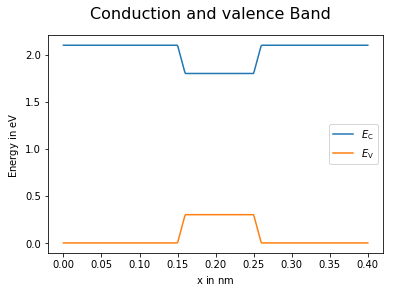

In [3]:
# Conduction and valence band

# Semiconductor ourside the quantum well
Ec_AlGaAs1   = 2.1
Ev_AlGaAs1   = 0.0

# Quantum well
Ec_AlGaAs2 = 1.8
Ev_AlGaAs2 = 0.3


#Doping outside the quantum well

Na = -1E24
Nd = 1E24

x1 = 150E-9
x2 = 160E-9
x3 = 250E-9
x4 = 260E-9

for i in range(0, parameters.n):
    if parameters.pos_x[i] < x1:
        parameters.Ec[i] = Ec_AlGaAs1
        parameters.Ev[i] = Ev_AlGaAs1
        parameters.C[i] = Na
        
    elif parameters.pos_x[i] < x2:
        parameters.Ec[i] = (
                        Ec_AlGaAs1 
                        -
                        (Ec_AlGaAs1 - Ec_AlGaAs2)*(parameters.pos_x[i] - x1)
                        /
                        (x2 - x1)
        )
        parameters.Ev[i] = (
                        Ev_AlGaAs1
                        -
                        (Ev_AlGaAs1 - Ev_AlGaAs2)*(parameters.pos_x[i] - x1)
                        /
                        (x2 - x1)
        )
        
        
    elif parameters.pos_x[i] < x3:
        parameters.Ec[i] = Ec_AlGaAs2
        parameters.Ev[i] = Ev_AlGaAs2
        parameters.C[i]  = 0.
    elif parameters.pos_x[i] < x4:
        parameters.Ec[i] = (
                        Ec_AlGaAs2
                        +
                        (Ec_AlGaAs1 - Ec_AlGaAs2)*(parameters.pos_x[i] - x3)
                        /
                        (x4 - x3)
        )
        parameters.Ev[i] = (
                            Ev_AlGaAs2
                            +
                            (Ev_AlGaAs1 - Ev_AlGaAs2)*(parameters.pos_x[i] - x3)
                            /
                            (x4 - x3)
        )
        
    else:
        parameters.Ec[i] = Ec_AlGaAs1
        parameters.Ev[i] = Ev_AlGaAs1 
        parameters.C[i] = Nd
    
    
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence Band", fontsize=16)

axis.plot(1E6*parameters.pos_x, parameters.Ec, label=r'$E_\mathrm{C}$')
axis.plot(1E6*parameters.pos_x, parameters.Ev, label=r'$E_\mathrm{V}$')

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

#plt.ylim(-.4, 2.4)

axis.legend()

The following function calculates the potential according the doping level.

In [4]:
parameters.init_potential()

Now, we plot the potential according the doping level.

<function matplotlib.pyplot.show(*args, **kw)>

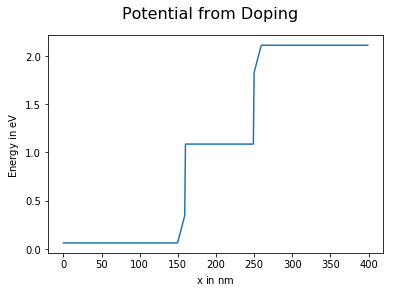

In [5]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from Doping", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

axis.plot(parameters.u[0::3])
plt.show

Now, let's plot the band diagramm considering diffusion but no biasing.<br>
One Simulation **solver.solve_no_bias()** must be performed befor simulatoins with biasing.

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


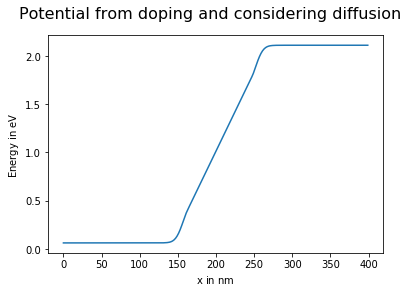

In [6]:
solver.solve_no_bias()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from doping and considering diffusion", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"Energy in $\mathrm{eV}$")

axis.plot(parameters.u[0::3])

plt.show()

Now, let's apply a voltage of $0\,\mathrm{mV}$ ! <br>

Plot the:
* potential,
* electron and hole density,
* electron and hole current density, and

Norm of b before loop:
3.7751244693894584e-15
Norm of b:  23296000001.492733
Norm of x: 0.23420476012710364
Norm of b:  1554.1818574506517
Norm of x: 0.005942475783385944
Norm of b:  0.04713889761992113
Norm of x: 4.851289162996653e-05
Norm of b:  0.0031515069890539157
Norm of x: 3.6873432882172303e-09
Norm of b:  0.0020664062181936114
Norm of x: 1.0130414429083428e-14
Norm of b:  0.0021960176847153935
Norm of x: 2.034286371035811e-14


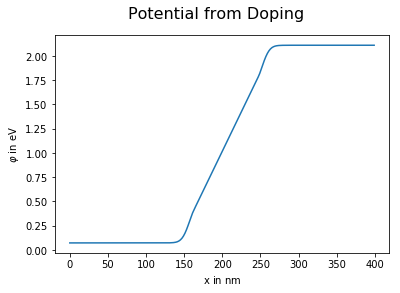

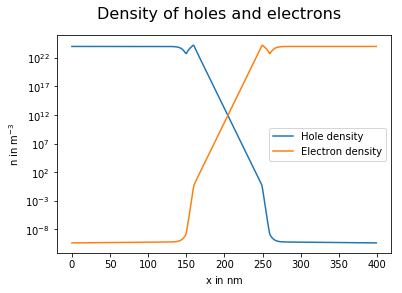

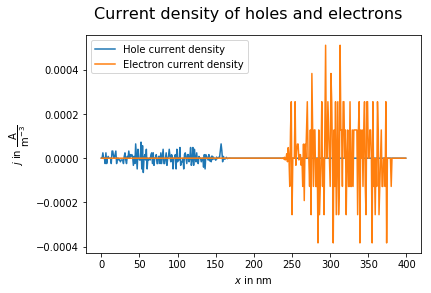

In [7]:
solver.solve_no_bias()

# The bernoulli function is approximated by polynome of degree 4
parameters.bernoulli_limit = 1E0

bias_point = 0.01
print("Norm of b before loop:")
print(np.linalg.norm(parameters.b))

solver.solve_bias(bias_point,0)

# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from Doping", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"$\varphi$ in $\mathrm{eV}$")

axis.plot(parameters.u[0::3], label='Potential')
plt.show()


# Quasi fermi levels of electrons and holes
#fig, axis = plt.subplots(1,1, sharey=True)
#fig.suptitle("Quasi fermi levels of holes and electrons", fontsize=16)

#axis.plot(parameters.u[1::3], label='Quasi fermi levels of hole')
#axis.plot(parameters.u[2::3], label='Quasi fermi levels of electrons')
#axis.legend()
#plt.show()



# Electron and hole density
calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

plt.xlabel(r"x in $\mathrm{nm}$")
plt.ylabel(r"n in $\mathrm{m^{-3}}$")

axis.semilogy(p, label='Hole density')
axis.semilogy(n, label='Electron density')
axis.legend()
plt.show()


# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

plt.xlabel(r"$x$ in $\mathrm{nm}$")
plt.ylabel(r"$j$ in $\mathrm{\dfrac{A}{m^{-3}}}$")

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')
axis.legend()
plt.show()

The total current density is composed by the hole and electron current density. <br>

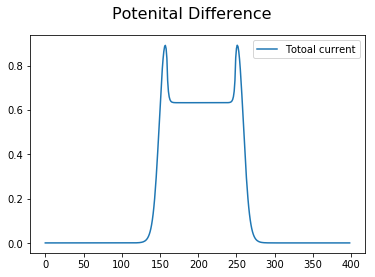

In [8]:
solver.solve_no_bias()

pot_diff = np.divide(np.diff(parameters.u[0::3]),parameters.Ut)

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potenital Difference", fontsize=16)

axis.plot(pot_diff, label='Totoal current')

axis.legend()
plt.show()


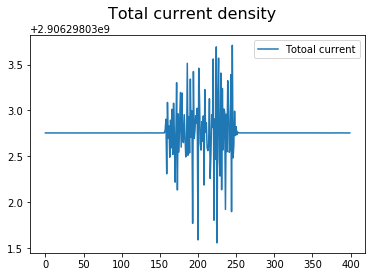

2906298032.7582116

In [15]:
j_total = hole_current_density() + electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Total current density", fontsize=16)

axis.plot(j_total, label='Totoal current')

axis.legend()
plt.show()

np.mean(j_total)

Now let's simulate a voltage sweep up to get the diode characteristic. <br>
For the simulation to converge, the voltage must be ramped up slowly.<br>
The bias points are printed and stored in the arrays **voltage** and **current_density**.

In [10]:
u_start = 0.0
u_stop  = 2.0
u_step  = 0.05
voltage = []
current_density = []

bias_points = np.linspace(u_start, u_stop, int((u_stop-u_start)/u_step + 1))
for bias_point in bias_points:

    solver.solve_bias(bias_point,0)   
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(bias_point)
    current_density.append(j)
    print(bias_point, ",", j)
  

Norm of b:  263720.56188217486
Norm of x: 1.5448876538949342e-06
Norm of b:  0.10493739375188488
Norm of x: 2.4903876086809516e-12
Norm of b:  0.0022490129746886973
Norm of x: 1.6674939755046613e-14
Norm of b:  0.0018283318295480358
Norm of x: 1.251434685711255e-14
Norm of b:  0.0018668139458809028
Norm of x: 1.709602000160772e-14
0.0 , 3.448961949358449e-06
Norm of b:  116480000000.00006
Norm of x: 1.1712999358608445
Norm of b:  991.1839488152714
Norm of x: 0.17001730931965525
Norm of b:  1.0031686221205458
Norm of x: 0.02974463137341189
Norm of b:  0.003096248680820851
Norm of x: 0.0014995405776473643
Norm of b:  0.002057857292546756
Norm of x: 4.168241406910056e-06
Norm of b:  0.002366310883055872
Norm of x: 3.776354694335961e-11
Norm of b:  0.002219589209363542
Norm of x: 1.294969179631126e-14
Norm of b:  0.0022101022234850484
Norm of x: 5.1687247953721136e-15
Norm of b:  0.0021492634933686105
Norm of x: 2.2856776815930392e-14
0.05 , -2.3399835428839228e-06
Norm of b:  116480000000

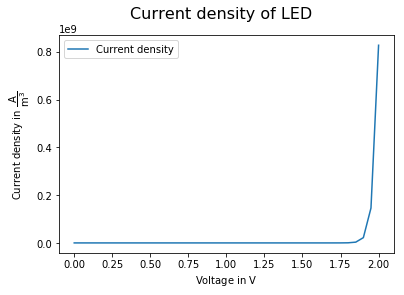

In [11]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of LED", fontsize=16)

axis.plot(voltage, current_density, label='Current density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Current density in $\mathrm{\dfrac{A}{m^3}}$")

axis.legend()
#plt.ylim(-1E-6,1E-6)
plt.show()

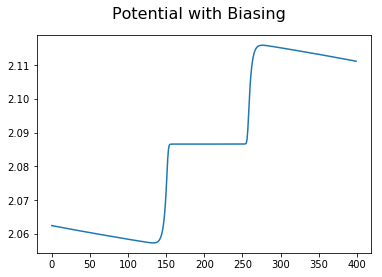

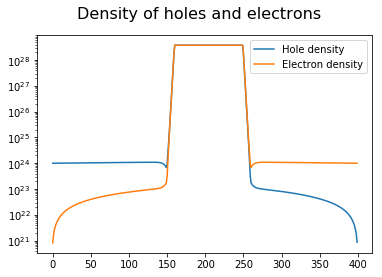

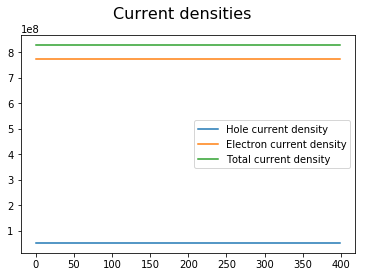

/home/pabele/anaconda3/lib/python3.7/site-packages/matplotlib/ticker.py:2241: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  "Data has no positive values, and therefore cannot be "


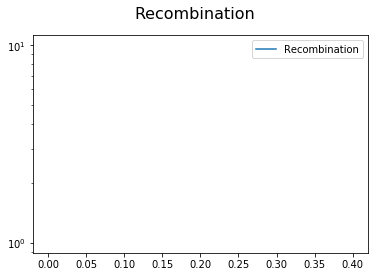

In [12]:
# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential with Biasing", fontsize=16)

axis.plot(parameters.u[0::3], label='Potential')
plt.show()


# Electron and hole density
calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

#plt.ylim(1E20)

axis.semilogy(p, label='Hole density')
axis.semilogy(n, label='Electron density')
axis.legend()
plt.show()


# Current densities
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current densities", fontsize=16)

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')
axis.plot(j_n + j_p, label='Total current density')
axis.legend()
plt.show()

# Recombination
calc_recombination()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Recombination", fontsize=16)

axis.semilogy(1E6*parameters.pos_x,
                parameters.q*parameters.recombination*parameters.dx,
                label='Recombination')

axis.legend()
plt.show()

Now, we start to increas recombination.

Norm of b:  3044097455193.663
Norm of x: 0.4880100240117288
Norm of b:  1119844933365.3542
Norm of x: 0.48684259682647596
Norm of b:  411942122661.84235
Norm of x: 0.48351087922132235
Norm of b:  151509981488.4957
Norm of x: 0.4785745392990376
Norm of b:  55693664442.51762
Norm of x: 0.47284663670946786
Norm of b:  20436817491.623005
Norm of x: 0.4641464093858362
Norm of b:  7459893429.269648
Norm of x: 0.44629498950646923
Norm of b:  2682546997.208767
Norm of x: 0.40376964962175754
Norm of b:  928633581.4375211
Norm of x: 0.30803446266347173
Norm of b:  292784691.4906628
Norm of x: 0.15222010188831622
Norm of b:  62646278.7057088
Norm of x: 0.02897782940906641
Norm of b:  2982433.9711998985
Norm of x: 0.0008738500813542812
Norm of b:  3977.3526725481297
Norm of x: 7.610080136634532e-07
Norm of b:  6.84433895162672
Norm of x: 5.765715508200944e-13
Norm of b:  6.529511860666048
Norm of x: 3.862429362583925e-15
Norm of b:  6.270342805263238
Norm of x: 3.0181052806692366e-15
Norm of b:  6

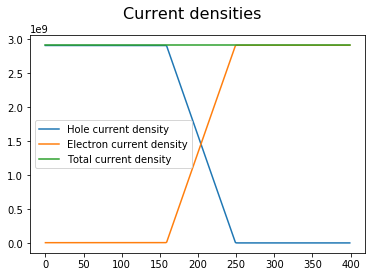

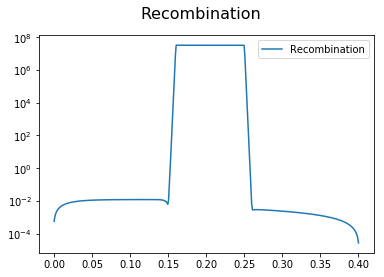

In [13]:
parameters.Cau = np.full(parameters.n, 1E-18)

#parameters.Cau = np.full(parameters.n, 2.3E-13*1E-8)


solver.solve_bias(bias_point,0)   

# Current densities
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current densities", fontsize=16)

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')
axis.plot(j_n + j_p, label='Total current density')
axis.legend()
plt.show()

calc_recombination()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Recombination", fontsize=16)

axis.semilogy(1E6*parameters.pos_x,
              parameters.q*parameters.recombination*parameters.dx,
              label='Recombination')

axis.legend()
plt.show()

In [14]:
print(Nc, Nv)

6.515133531824195e+23 1.118597405794417e+25


In [15]:
print(parameters.Nc[0], parameters.Nv[0])

2.81e+25 1.83e+25
